# NGSO SLS — Live Coverage Explorer (Slice A analysis on a live constellation)

The notebook-01 coverage analysis (n-in-view, max-elevation, availability curves, latitude
profile, elevation sweep) computed on the **live constellation pulled from Spacetime**
(fss01-demo: 150-sat, 10×15, 53°, ~1157 km) instead of a Walker preset.

**Read-only guarantee:** the pull uses `StorageEntityStore`, which wires only
`Store.Get` / `Store.GetEntities` — no write RPC exists on the client. Nothing in this
notebook alters the instance model or provisioning.

**Data source:** live raw Store (default `localhost:9999`, override `SLS_STORE_TARGET`)
with automatic fallback to the textproto dump (`SLS_DUMP_DIR`).


In [1]:
# === Setup & live pull ===
import os, sys, pathlib, datetime
_REPO = pathlib.Path.cwd().resolve()
while _REPO != _REPO.parent and not (_REPO / "ngso_sls").is_dir():
    _REPO = _REPO.parent
if not (_REPO / "ngso_sls").is_dir():                    # cwd outside a checkout:
    _anchor = pathlib.Path("/workspace/spacetime-sls")    # sandbox/host mount anchor
    if (_anchor / "ngso_sls").is_dir():
        _REPO = _anchor
if not (_REPO / "ngso_sls").is_dir():                    # bare runtime (Colab): clone + install
    import subprocess
    _url = "https://github.com/luca-aalyria/spacetime-sls.git"
    try:                                                  # private repo: Colab secret GITHUB_TOKEN
        from google.colab import userdata
        _tok = userdata.get("GITHUB_TOKEN")
        if _tok:
            _url = _url.replace("https://", f"https://{_tok}@")
    except Exception:
        pass
    subprocess.run(["git", "clone", "-q", _url], check=True)
    _REPO = (pathlib.Path.cwd() / "spacetime-sls").resolve()
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", str(_REPO)], check=False)
for p in (str(_REPO), str(_REPO / "vendor" / "spacetime_api_stubs")):
    if p not in sys.path:
        sys.path.insert(0, p)
import numpy as np
import matplotlib.pyplot as plt
from ngso_sls.spacetime.nmts_adapter import platforms_to_elements

TARGET = os.environ.get("SLS_STORE_TARGET", "localhost:9999")
try:
    from ngso_sls.spacetime.client import StorageEntityStore
    _store = StorageEntityStore(TARGET)
    entities = _store.list_entities()
    rels = _store.list_relationships()
    SOURCE = f"live {TARGET}"
except Exception as exc:
    print(f"live store unavailable -> loading dump\n  cause: {exc}\n"
          "  (live needs a kubectl port-forward to svc/storage:9999 running on THIS machine"
          " — sandbox/host each need their own; see tools/sandbox_live_setup.sh)")
    import glob
    from google.protobuf import text_format
    from ngso_sls.spacetime import _deps
    from ngso_sls.spacetime.client import _NmtsEntityView
    DUMP_DIR = os.environ.get("SLS_DUMP_DIR") or next(
        (str(d) for d in (_REPO.parent / "fss01-demo-dump",
                          pathlib.Path("/workspace/fss01-demo-dump")) if d.is_dir()), None)
    def _load(pattern):
        out = []
        for path in sorted(glob.glob(f"{DUMP_DIR}/{pattern}")):
            box = _deps.storage_pb2.TxtpbEntities()
            with open(path) as f:
                text_format.Parse(f.read(), box)
            out.extend(box.entity)
        return out
    entities = [_NmtsEntityView(e.nmts_entity)
                for e in _load("nmts/entities_ek_*.txtpb")]
    rels = [e.nmts_relationship for e in _load("nmts/relationships_rk_contains.txtpb")]
    SOURCE = f"dump {DUMP_DIR}"

built = platforms_to_elements(entities, rels)
elems, plane_uid = built["elems"], built["plane_uid"]
print(f"source: {SOURCE}")
print(f"served Keplerian satellites: {elems.shape[0]} "
      f"(skipped {len(built['skipped'])} ground/non-Keplerian platforms)")


source: live localhost:9999
served Keplerian satellites: 150 (skipped 227 ground/non-Keplerian platforms)


altitude: 1157-1157 km | inclination: 53.0-53.0 deg | 10 planes x 15 sats


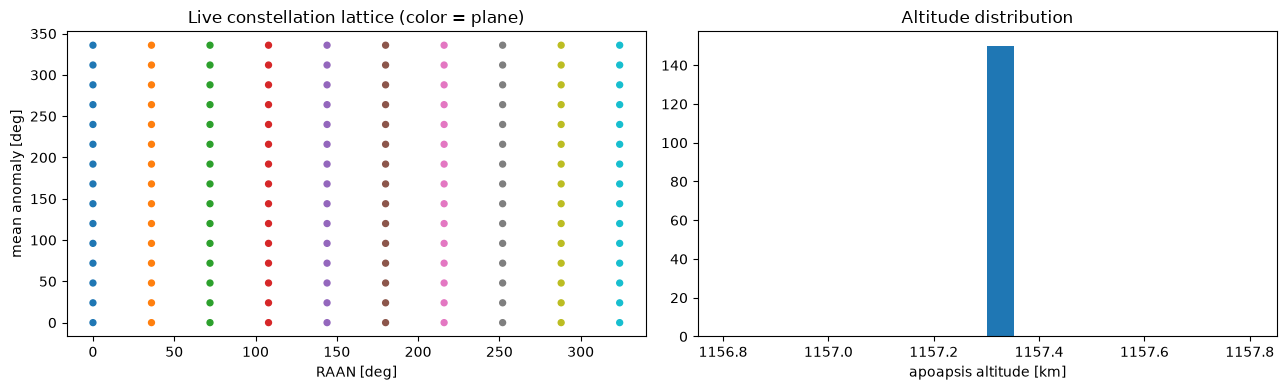

In [2]:
# === What constellation is this? (derived from the live elements) ===
from ngso_sls.constants import RE_EQ
alt_km = elems[:, 0] * (1 + elems[:, 1]) - RE_EQ
inc_deg = np.degrees(elems[:, 2])
raan_deg = np.degrees(elems[:, 3])
M_deg = np.degrees(elems[:, 5])
n_planes = len(np.unique(plane_uid))
print(f"altitude: {alt_km.min():.0f}-{alt_km.max():.0f} km | inclination: "
      f"{inc_deg.min():.1f}-{inc_deg.max():.1f} deg | {n_planes} planes x "
      f"{elems.shape[0] // max(n_planes,1)} sats")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sc = ax[0].scatter(raan_deg, M_deg, c=plane_uid, cmap="tab10", s=18)
ax[0].set_xlabel("RAAN [deg]"); ax[0].set_ylabel("mean anomaly [deg]")
ax[0].set_title("Live constellation lattice (color = plane)")
ax[1].hist(alt_km, bins=20, color="tab:blue")
ax[1].set_xlabel("apoapsis altitude [km]"); ax[1].set_title("Altitude distribution")
plt.tight_layout(); plt.show()


In [3]:
# === Service parameters FROM THE MODEL (NMTS antenna field-of-regard) ===
# Min elevation is not an SLS guess — the instance models it: ek_antenna carries
# field_of_regard (conic half-angle from boresight). For a zenith-pointed ground antenna,
# min_elevation = 90 - outer_half_angle. (azimuth_elevation_mask would refine this with
# terrain horizons; none are set in this scenario.)
EK_ANTENNA = 40
def _min_elev_from_model(prefix):
    angles = [e.antenna.field_of_regard.conic.outer_half_angle_deg
              for e in entities if getattr(e, "kind", -1) == EK_ANTENNA
              and str(e.id).startswith(prefix) and e.antenna.HasField("field_of_regard")]
    return (90.0 - float(np.median(angles))) if angles else None

MODEL_MIN_ELEV_UT = _min_elev_from_model("user-terminal")
MODEL_MIN_ELEV_GW = _min_elev_from_model("gateway")
print(f"model-derived min elevation: user links {MODEL_MIN_ELEV_UT} deg, "
      f"feeder links {MODEL_MIN_ELEV_GW} deg")


model-derived min elevation: user links 25.0 deg, feeder links 10.0 deg


## Coverage Explorer — notebook-01 controls, live constellation

Identical GUI to notebook 01 (service area, min elevation, H3 resolution, duration/step,
**k**, sharding, make-before-break gate, terrain, opacity) — only the constellation
section is gone: the shape above is **fixed from the live NMTS model**. Min elevation is
pre-set from the model's antenna field-of-regard (change the slider to override).

Each **Run simulation** appends a results tab (availability map, sats-in-view map, MBB
feasibility, latitude profile, histogram) and writes a self-describing CSV — previous runs
are kept for comparison, so probe k grades by re-running with different **k** values.
*(The tabs are live widgets: run the notebook in Jupyter/Colab to see them — they don't
render in static HTML exports.)*


In [4]:
# === Coverage Explorer (controls) ===
from ngso_sls.explorer import LiveCoverageExplorer

explorer = LiveCoverageExplorer(
    elems, plane_uid,
    label=SOURCE,
    csv_path="live_coverage_availability.csv",
    min_elev_deg=MODEL_MIN_ELEV_UT)           # model-derived; slider overrides
explorer.display()


In [5]:
# === Results (each run appends a tab) ===
from IPython.display import display
display(explorer.results)


In [6]:
# === Auto-run once with the current settings (so Run-All produces a result) ===
explorer.run()


**Reading the results** — this is the Slice-A analysis of notebook 01, but the
constellation under test is whatever the live instance is actually flying. The 53°
inclination shows as the availability band in the global map and the sats-in-view
latitude profile (peak near ±53°, zero at the poles). The elevation sweep quantifies how
much margin the scenario has against stricter masks. Elements + availability are exported
to `outputs/` for downstream comparison against Walker presets (e.g. notebook 01 with
matched parameters).